### Decision Trees
A decision tree works by asking a sequence of questions, and each split tries to increase certainty about the class label.



In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv('./data/mushroom_data.csv', sep=';')

df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

In [4]:
threshold = len(df) * 0.90

df_cleaned = df.dropna(thresh=threshold, axis=1)

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-color             61069 non-null  object 
 4   does-bruise-or-bleed  61069 non-null  object 
 5   gill-color            61069 non-null  object 
 6   stem-height           61069 non-null  float64
 7   stem-width            61069 non-null  float64
 8   stem-color            61069 non-null  object 
 9   has-ring              61069 non-null  object 
 10  ring-type             58598 non-null  object 
 11  habitat               61069 non-null  object 
 12  season                61069 non-null  object 
dtypes: float64(3), object(10)
memory usage: 6.1+ MB


In [5]:
df_cleaned['ring-type'].value_counts()

ring-type
f    48361
e     2435
z     2118
l     1427
r     1399
p     1265
g     1240
m      353
Name: count, dtype: int64

In [16]:
type(filler)

pandas.core.series.Series

In [17]:
filler

0    f
Name: ring-type, dtype: object

In [21]:
import warnings 

warnings.filterwarnings('ignore')

In [ ]:
# get the mode of the class
filler = df_cleaned['ring-type'].mode()

# df_cleaned['ring-type'] = df_cleaned['ring-type'].fillna(filler[0], axis=0)
# df_cleaned['ring-type'] = df_cleaned['ring-type'].fillna(filler[0])

df_cleaned['ring-type'].fillna(filler[0], inplace=True)

df_cleaned['ring-type'].isna().sum()

0

In [19]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-color             61069 non-null  object 
 4   does-bruise-or-bleed  61069 non-null  object 
 5   gill-color            61069 non-null  object 
 6   stem-height           61069 non-null  float64
 7   stem-width            61069 non-null  float64
 8   stem-color            61069 non-null  object 
 9   has-ring              61069 non-null  object 
 10  ring-type             61069 non-null  object 
 11  habitat               61069 non-null  object 
 12  season                61069 non-null  object 
dtypes: float64(3), object(10)
memory usage: 6.1+ MB


In [25]:
type(df_cleaned.columns)

pandas.core.indexes.base.Index

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
#use for loop to encode our categorical to numeric
for col in df_cleaned.columns:
    df_cleaned[col] = encoder.fit_transform(df_cleaned[col])   #label encoder

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   class                 61069 non-null  int32
 1   cap-diameter          61069 non-null  int64
 2   cap-shape             61069 non-null  int32
 3   cap-color             61069 non-null  int32
 4   does-bruise-or-bleed  61069 non-null  int32
 5   gill-color            61069 non-null  int32
 6   stem-height           61069 non-null  int64
 7   stem-width            61069 non-null  int64
 8   stem-color            61069 non-null  int32
 9   has-ring              61069 non-null  int32
 10  ring-type             61069 non-null  int32
 11  habitat               61069 non-null  int32
 12  season                61069 non-null  int32
dtypes: int32(10), int64(3)
memory usage: 3.7 MB


In [27]:
#independent and dependent variables
X = df_cleaned.drop('class', axis=1)
y = df_cleaned['class']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=254)

In [28]:
#instantiate our tree
dt = DecisionTreeClassifier(random_state=254)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=254)

In [34]:
from sklearn.metrics import accuracy_score, roc_curve, RocCurveDisplay, auc

#predictions
y_preds = dt.predict(X_test)

accuracy_score(y_test, y_preds)

0.9853719775121446

In [30]:
from sklearn.linear_model import LogisticRegression

#instantiate 
lr = LogisticRegression()

lr.fit(X_train, y_train)



LogisticRegression()

In [31]:
#predictions in lr
lr_y_preds = lr.predict(X_test)

accuracy_score(y_test, lr_y_preds)

0.5814093117187926

In [33]:
dt.predict_proba(X_test)[:,1]


array([0., 0., 0., ..., 0., 0., 1.])

In [36]:
lr_y_prob = lr.predict_proba(X_test)[:, 1]
dt_y_prob = dt.predict_proba(X_test)[:, 1]


lr_fpr, lr_tpr, i = roc_curve(y_test, lr_y_prob)
dt_fpr, dt_tpr, i = roc_curve(y_test, dt_y_prob)

lr_auc = auc(lr_fpr, lr_tpr)
dt_auc = auc(dt_fpr, dt_tpr)

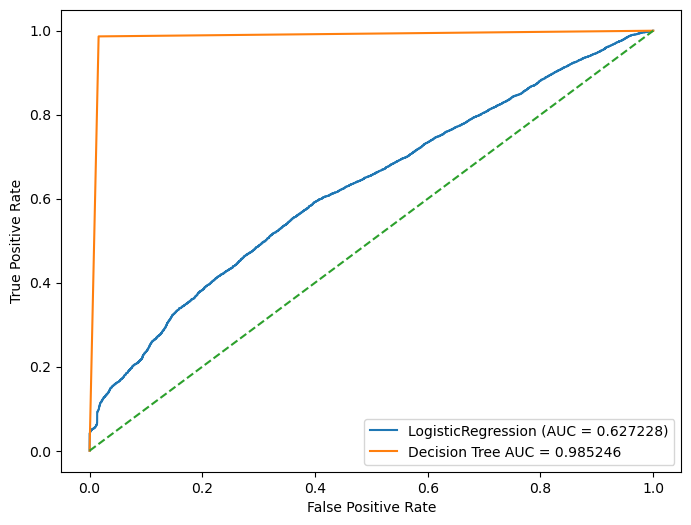

In [40]:
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'LogisticRegression (AUC = {lr_auc:2f})')
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree AUC = {dt_auc:2f}')
plt.plot([0,1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

#### Hyperparameter tuning 

#### GridSearch


CART Trees(Classification and Regression Trees)

In [ ]:
tree = DecisionTreeClassifier()